# QML for Passive Sonar — quick tour

Three smoke-size demos that runnable in under 10 minutes on CPU:

1. **SAV** algorithm on a synthetic propeller signal.
2. **HQ-CNN** (qubit PQC variant) forward + backward pass on dummy spectrograms.
3. **HQ-CNN MerLin** (photonic variant) forward + backward pass.

Run from the paper folder so the `lib/` imports resolve:

```bash
cd papers/qml_passive_sonar
jupyter notebook notebook.ipynb
```


In [1]:
import os, sys
# Allow `import lib.*` regardless of cwd.
_here = os.path.abspath('.')
if _here not in sys.path: sys.path.insert(0, _here)
import numpy as np
import torch
import matplotlib.pyplot as plt
torch.manual_seed(0); np.random.seed(0)


## 1. SAV on a synthetic propeller signal

Generate 30 s of a class-B-like signal (two tonals + harmonics + coloured noise) and run `compute_sav`.

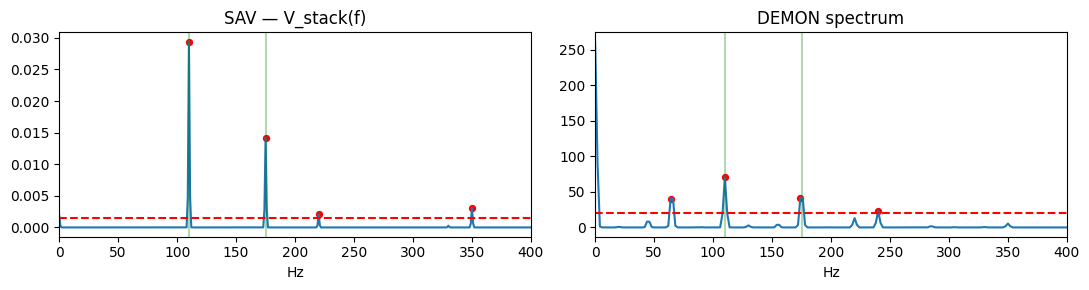

SAV peaks @ [110. 175. 220. 350.]
expected   @ (110.0, 175.0)


In [2]:
from lib.data import _generate_synthetic_signal
from lib.sav import compute_sav
from lib.demon import compute_demon

rng = np.random.default_rng(0)
sr = 4000
duration = 30.0
tonal_sets = [(47.0, 91.0), (110.0, 175.0), (63.0, 130.0, 220.0), (38.0, 80.0, 150.0, 305.0), ()]
x = _generate_synthetic_signal(rng, class_idx=1, duration_s=duration, sr=sr, tonal_sets=tonal_sets, background_class=4)

sav = compute_sav(x, sr=sr, segment_duration=4.0, stacking=2, threshold_eta=2.0)
dem = compute_demon(x, sr=sr, band=(20.0, 1800.0), window_duration=0.5, threshold_eta=2.0)

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].plot(sav.frequencies, sav.v_stack); axes[0].axhline(sav.threshold, color='r', ls='--')
axes[0].scatter(sav.frequencies[sav.peak_indices], sav.v_stack[sav.peak_indices], c='red', s=18)
axes[0].set_xlim(0, 400); axes[0].set_title('SAV — V_stack(f)'); axes[0].set_xlabel('Hz')
axes[1].plot(dem.frequencies, dem.spectrum); axes[1].axhline(dem.threshold, color='r', ls='--')
axes[1].scatter(dem.frequencies[dem.peak_indices], dem.spectrum[dem.peak_indices], c='red', s=18)
axes[1].set_xlim(0, 400); axes[1].set_title('DEMON spectrum'); axes[1].set_xlabel('Hz')
for ax in axes:
    for f0 in tonal_sets[1]: ax.axvline(f0, color='green', alpha=0.3)
plt.tight_layout(); plt.show()
print('SAV peaks @', np.round(sav.frequencies[sav.peak_indices], 1))
print('expected   @', tonal_sets[1])

## 2. HQ-CNN forward + backward (qubit PQC)

Small smoke model: 32×32 input, fc_dim=32, 4 qubits, 2 layers.

In [3]:
from lib.models import HQCNN
model = HQCNN(num_classes=5, fc_dim=32, image_size=32, n_qubits=4, n_layers=2)
x = torch.randn(4, 3, 32, 32)
y = model(x)
print('output:', y.shape)
print('trainable params:', sum(p.numel() for p in model.parameters()))
y.sum().backward()
print('backward OK; PQC has', sum(p.numel() for p in model.pqc.parameters()), 'quantum params')

output: torch.Size([4, 5])
trainable params: 2886445
backward OK; PQC has 16 quantum params


## 3. HQ-CNN MerLin (photonic variant) forward + backward

Same backbone, but the PQC is replaced by a `merlin.QuantumLayer` (4 modes / 2 photons / unbunched).

In [4]:
from lib.models_merlin import HQCNNMerLin
model = HQCNNMerLin(num_classes=5, fc_dim=32, image_size=32, n_modes=4, n_photons=2)
x = torch.randn(4, 3, 32, 32)
y = model(x)
print('output:', y.shape)
print('photonic output_size:', model.output_size)
print('trainable params:', sum(p.numel() for p in model.parameters()))
y.sum().backward()
print('backward OK; photonic layer has', sum(p.numel() for p in model.quantum_layer.parameters()), 'photonic params')

output: torch.Size([4, 5])
photonic output_size: 6
trainable params: 2886479
backward OK; photonic layer has 36 photonic params
